In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
import pandas as pd
df = pd.read_csv('tmdb_full.csv')
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movieId', 'tmdbId', 'title_ml', 'genres_ml',
       'avg_rating', 'rating_count', 'tags_text', 'content'],
      dtype='object')

In [17]:
df['overview'].iloc[2]

'A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE.'

In [18]:
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Shape: (4806, 28)

Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'movieId', 'tmdbId', 'title_ml', 'genres_ml', 'avg_rating', 'rating_count', 'tags_text', 'content']

Dtypes:
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_average,vote_count,movieId,tmdbId,title_ml,genres_ml,avg_rating,rating_count,tags_text,content
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,7.2,11800,72998.0,19995.0,Avatar (2009),Action|Adventure|Sci-Fi|IMAX,3.594313,35043.0,aliens beautiful scenery futuristic graphic de...,"In the 22nd century, a paraplegic Marine is di..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,6.9,4500,53125.0,285.0,Pirates of the Caribbean: At World's End (2007),Action|Adventure|Comedy|Fantasy,3.390636,15453.0,adventure convoluted poor plot surreal Bill Ni...,"Captain Barbossa, long believed to be dead, ha..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,6.3,4466,136020.0,206647.0,Spectre (2015),Action|Adventure|Crime,3.387448,5513.0,007 atmospheric Ben Wishaw Bond Daniel Craig d...,A cryptic message from Bond’s past sends him o...


In [19]:
# Check key text columns
print("=== Sample 'overview' ===")
print(df['overview'].iloc[0])
print("\n=== Sample 'content' ===")
print(df['content'].iloc[0][:500])
print("\n=== Sample 'genres' ===")
print(df['genres'].iloc[0])
print("\n=== Sample 'keywords' ===")
print(df['keywords'].iloc[0])
print("\n=== Sample 'tags_text' ===")
print(df['tags_text'].iloc[0][:300] if pd.notna(df['tags_text'].iloc[0]) else "NaN")

=== Sample 'overview' ===
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.

=== Sample 'content' ===
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. [{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9

=== Sample 'genres' ===
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

=== Sample 'keywords' ===
[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386,

## Phase 2 — Data Cleaning & Preparation

In [20]:
import ast
import json
import re

# ── Helper: safely parse JSON-like list columns ──
def parse_json_names(text):
    """Extract 'name' values from a JSON-like list string, e.g. [{"id":1,"name":"Action"}]."""
    if pd.isna(text) or text.strip() == '':
        return []
    try:
        items = json.loads(text.replace("'", '"'))
        return [item['name'] for item in items if 'name' in item]
    except (json.JSONDecodeError, TypeError):
        return []

# ── 1. Parse structured columns ──
df['genre_list'] = df['genres'].apply(parse_json_names)
df['keyword_list'] = df['keywords'].apply(parse_json_names)
df['production_company_list'] = df['production_companies'].apply(parse_json_names)
df['production_country_list'] = df['production_countries'].apply(parse_json_names)
df['spoken_language_list'] = df['spoken_languages'].apply(parse_json_names)

# Readable string versions
df['genres_clean'] = df['genre_list'].apply(lambda x: ', '.join(x))
df['keywords_clean'] = df['keyword_list'].apply(lambda x: ', '.join(x))

# ── 2. Handle missing values ──
df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')
df['tags_text'] = df['tags_text'].fillna('')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Drop rows where runtime is missing (only 2)
df = df.dropna(subset=['runtime']).copy()

# ── 3. Build a rich text description for each movie ──
def build_description(row):
    """Combine multiple text fields into one rich description for embedding."""
    parts = []
    parts.append(f"Title: {row['title']}.")
    if row['tagline']:
        parts.append(f"Tagline: {row['tagline']}.")
    if row['overview']:
        parts.append(f"Plot: {row['overview']}")
    if row['genres_clean']:
        parts.append(f"Genres: {row['genres_clean']}.")
    if row['keywords_clean']:
        parts.append(f"Keywords: {row['keywords_clean']}.")
    if row['tags_text']:
        parts.append(f"Tags: {row['tags_text'][:200]}.")
    if pd.notna(row['release_year']):
        parts.append(f"Year: {int(row['release_year'])}.")
    if pd.notna(row['vote_average']):
        parts.append(f"Rating: {row['vote_average']}/10.")
    return ' '.join(parts)

df['description'] = df.apply(build_description, axis=1)

print(f"Cleaned dataset shape: {df.shape}")
print(f"\n=== Sample description ===\n{df['description'].iloc[0][:500]}")
print(f"\n=== Columns added ===")
print([c for c in df.columns if c not in ['budget','genres','homepage','id','keywords','original_language',
       'original_title','overview','popularity','production_companies','production_countries',
       'release_date','revenue','runtime','spoken_languages','status','tagline','title',
       'vote_average','vote_count','movieId','tmdbId','title_ml','genres_ml','avg_rating',
       'rating_count','tags_text','content']])

Cleaned dataset shape: (4804, 37)

=== Sample description ===
Title: Avatar. Tagline: Enter the World of Pandora.. Plot: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Genres: Action, Adventure, Fantasy, Science Fiction. Keywords: culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, alien planet, cgi, marine, soldier, battle, love affair, anti war, power relations, mind 

=== Columns added ===
['genre_list', 'keyword_list', 'production_company_list', 'production_country_list', 'spoken_language_list', 'genres_clean', 'keywords_clean', 'release_year', 'description']


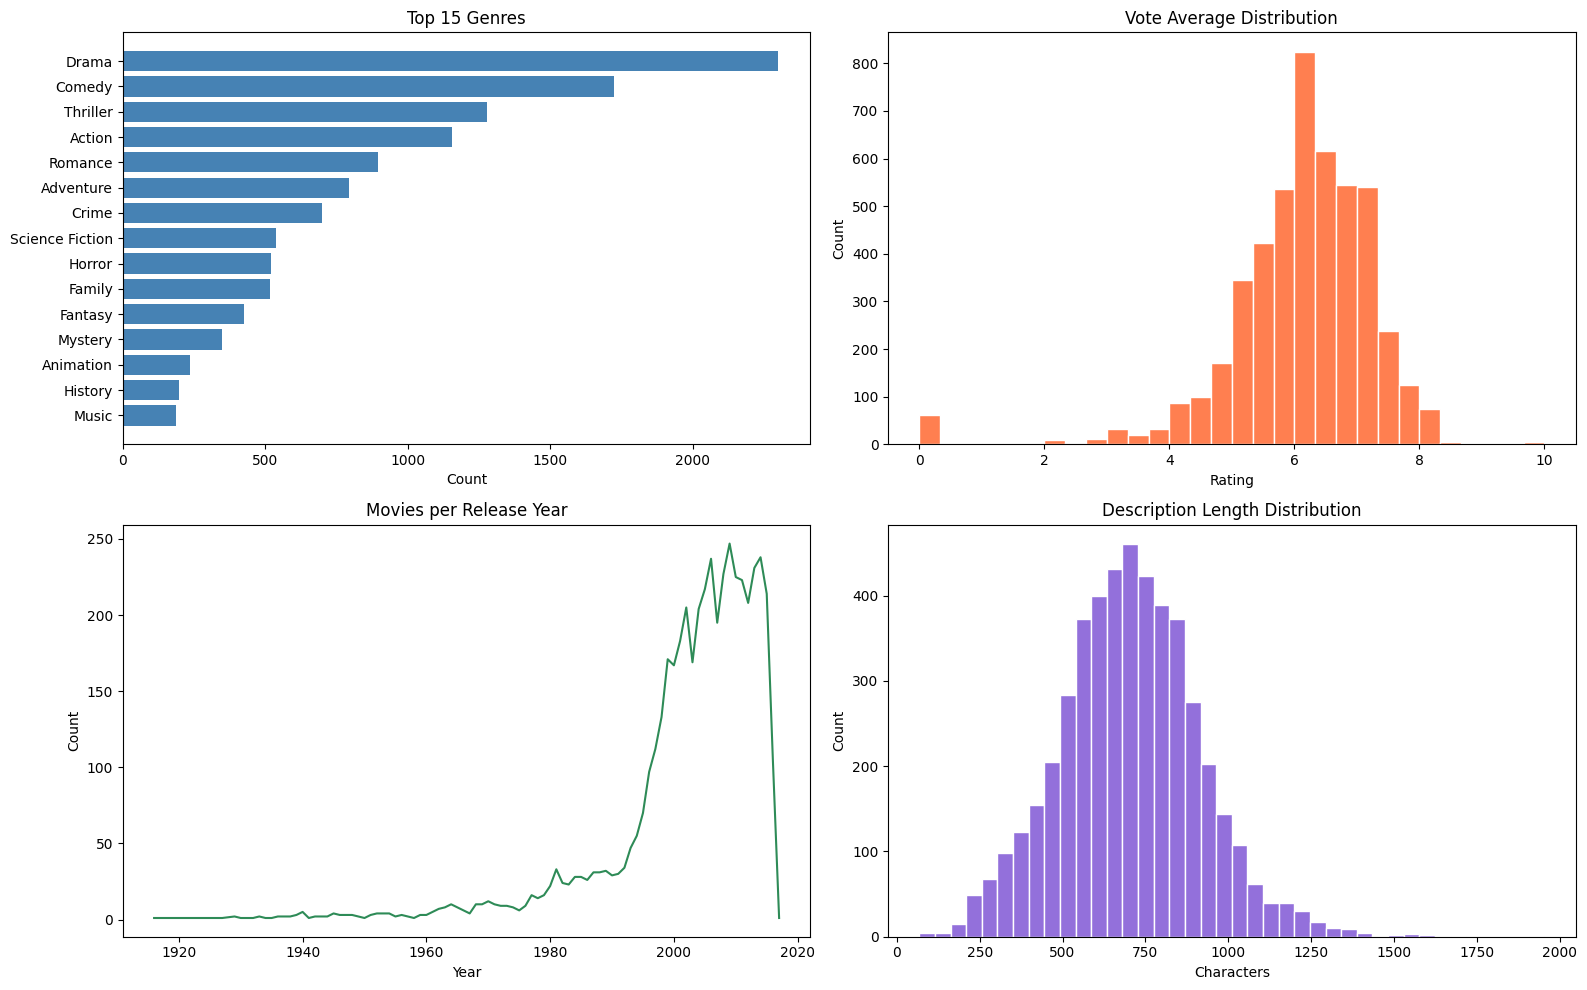


Description length — min: 68, median: 700, max: 1954


In [24]:
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Genre distribution
all_genres = [g for gl in df['genre_list'] for g in gl]
genre_counts = Counter(all_genres).most_common(15)
axes[0, 0].barh([g[0] for g in genre_counts][::-1], [g[1] for g in genre_counts][::-1], color='steelblue')
axes[0, 0].set_title('Top 15 Genres')
axes[0, 0].set_xlabel('Count')

# 2. Rating distribution
axes[0, 1].hist(df['vote_average'], bins=30, color='coral', edgecolor='white')
axes[0, 1].set_title('Vote Average Distribution')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Count')

# 3. Movies per year
year_counts = df['release_year'].dropna().astype(int).value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, color='seagreen')
axes[1, 0].set_title('Movies per Release Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Count')

# 4. Description length distribution
df['desc_length'] = df['description'].str.len()
axes[1, 1].hist(df['desc_length'], bins=40, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Description Length Distribution')
axes[1, 1].set_xlabel('Characters')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f"\nDescription length — min: {df['desc_length'].min()}, median: {df['desc_length'].median():.0f}, max: {df['desc_length'].max()}")

In [26]:
# Save cleaned dataset
cols_to_save = ['id', 'title', 'overview', 'tagline', 'genres_clean', 'keywords_clean',
                'release_year', 'runtime', 'vote_average', 'vote_count', 'popularity',
                'original_language', 'description', 'tags_text', 'genre_list', 'keyword_list']

df_clean = df[cols_to_save].reset_index(drop=True)

df_clean.to_csv('movies_cleaned.csv', index=False)

print(f"Saved cleaned dataset: {df_clean.shape}")
df_clean.head(3)

Saved cleaned dataset: (4804, 16)


,id,title,overview,tagline,genres_clean,keywords_clean,release_year,runtime,vote_average,vote_count,popularity,original_language,description,tags_text,genre_list,keyword_list
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",Enter the World of Pandora.,"Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...",2009.0,162.0,7.2,11800,150.437577,en,Title: Avatar. Tagline: Enter the World of Pan...,aliens beautiful scenery futuristic graphic de...,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","At the end of the world, the adventure begins.","Adventure, Fantasy, Action",,2007.0,169.0,6.9,4500,139.082615,en,Title: Pirates of the Caribbean: At World's En...,adventure convoluted poor plot surreal Bill Ni...,"[Adventure, Fantasy, Action]",[]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,A Plan No One Escapes,"Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...",2015.0,148.0,6.3,4466,107.376788,en,Title: Spectre. Tagline: A Plan No One Escapes...,007 atmospheric Ben Wishaw Bond Daniel Craig d...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi..."


## Phase 3 — Model Development

### 3.1 Generate Semantic Embeddings

In [27]:
from sentence_transformers import SentenceTransformer
import os
import pickle  
# 导入序列化模块pickle
# 由于生成向量非常耗时，我们会把计算好的结果存成一个二进制文件，下次直接读取

EMBEDDING_PATH = 'movie_embeddings.pkl'
# 定义存放向量文件的名称

# Use a high-quality model for semantic similarity, dimension 384
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings (cache to avoid recomputation)
if os.path.exists(EMBEDDING_PATH):
    with open(EMBEDDING_PATH, 'rb') as f:
        embeddings = pickle.load(f)
    print(f"Loaded cached embeddings: {embeddings.shape}")
else:
    descriptions = df['description'].tolist()
    embeddings = model.encode(descriptions, show_progress_bar=True, batch_size=64)
    with open(EMBEDDING_PATH, 'wb') as f:
        pickle.dump(embeddings, f)
    print(f"Generated and saved embeddings: {embeddings.shape}")

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 512.87it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 76/76 [03:35<00:00,  2.84s/it]

Generated and saved embeddings: (4804, 384)


### 3.2 Similarity-Based Recommendation Engine

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_by_title(title, df, embeddings, top_n=10):
    """Find movies similar to a given title using cosine similarity on embeddings."""
    matches = df[df['title'].str.lower() == title.lower()]
    if matches.empty:
        # Fuzzy fallback: partial match
        matches = df[df['title'].str.lower().str.contains(title.lower(), na=False)]
    if matches.empty:
        print(f"Movie '{title}' not found.")
        return pd.DataFrame()

    idx = matches.index[0]
    query_emb = embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(query_emb, embeddings)[0]

    # Exclude the query movie itself
    sim_scores = list(enumerate(sims))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]

    result_indices = [i for i, _ in sim_scores]
    result = df.iloc[result_indices][['title', 'genres_clean', 'release_year', 'vote_average', 'overview']].copy()
    result['similarity'] = [s for _, s in sim_scores]
    return result.reset_index(drop=True)

def recommend_by_query(query_text, df, embeddings, model, top_n=10):
    """Find movies similar to a free-text query using semantic search."""
    query_emb = model.encode([query_text])
    sims = cosine_similarity(query_emb, embeddings)[0]
    sim_scores = sorted(enumerate(sims), key=lambda x: x[1], reverse=True)[:top_n]

    result_indices = [i for i, _ in sim_scores]
    result = df.iloc[result_indices][['title', 'genres_clean', 'release_year', 'vote_average', 'overview']].copy()
    result['similarity'] = [s for _, s in sim_scores]
    return result.reset_index(drop=True)

print("Recommendation functions defined.")

Recommendation functions defined.


In [31]:
# Demo: Title-based recommendation
print("=" * 80)
print("Movies similar to 'The Dark Knight':")
print("=" * 80)
recs = recommend_by_title("The Dark Knight", df, embeddings, top_n=5)
display(recs[['title', 'genres_clean', 'release_year', 'vote_average', 'similarity']])

print("\n" + "=" * 80)
print("Semantic query: 'a romantic comedy set in Paris about finding love'")
print("=" * 80)
recs_q = recommend_by_query("a romantic comedy set in Paris about finding love", df, embeddings, model, top_n=5)
display(recs_q[['title', 'genres_clean', 'release_year', 'vote_average', 'similarity']])

Movies similar to 'The Dark Knight':


,title,genres_clean,release_year,vote_average,similarity
0,Batman Begins,"Action, Crime, Drama",2005.0,7.5,0.853273
1,The Dark Knight Rises,"Action, Crime, Drama, Thriller",2012.0,7.6,0.848006
2,Batman v Superman: Dawn of Justice,"Action, Adventure, Fantasy",2016.0,5.7,0.763654
3,Batman Forever,"Action, Crime, Fantasy",1995.0,5.2,0.707472
4,Watchmen,"Action, Mystery, Science Fiction",2009.0,7.0,0.695623



Semantic query: 'a romantic comedy set in Paris about finding love'


,title,genres_clean,release_year,vote_average,similarity
0,"Paris, je t'aime","Drama, Romance",2006.0,6.8,0.690265
1,Midnight in Paris,"Fantasy, Comedy, Romance",2011.0,7.4,0.651794
2,Amélie,"Comedy, Romance",2001.0,7.8,0.607393
3,Desire,"Drama, Romance",2011.0,4.1,0.587623
4,Before Sunrise,"Drama, Romance",1995.0,7.7,0.563172


### 3.3 LLM-Powered Query Interpretation

The LLM converts vague natural language queries into structured signals (genres, themes, mood, time period, etc.) to enhance retrieval quality beyond raw semantic matching.

In [33]:
!pip install openai

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 8.0 MB/s  0:00:00

   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- --------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
from openai import OpenAI

os.environ["OPENROUTER_API_KEY"] = "YOUR_OPENROUTER_API_KEY_HERE "

client = OpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    default_headers={
        "HTTP-Referer": "http://localhost",
        "X-Title": "Movie Recommender Project"
    }
)

# LLM_MODEL = "google/gemma-3-27b-it:free"
LLM_MODEL = "deepseek/deepseek-chat-v3.1"

def extract_llm_text(response):
    """Extract text from LLM response, handling reasoning-only models."""
    msg = response.choices[0].message
    # Prefer content (normal models put the answer here)
    if msg.content:
        return msg.content.strip()
    # Some free models put output in 'reasoning' instead of 'content'
    reasoning = getattr(msg, 'reasoning', None)
    if reasoning:
        # If reasoning contains JSON, extract it
        if '{' in reasoning:
            start = reasoning.find('{')
            end = reasoning.rfind('}')
            if start != -1 and end > start:
                return reasoning[start:end+1]
        return reasoning.strip()
    return ""

# Quick test
response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role": "user", "content": "Say hello in one short sentence."}],
    max_tokens=50,
)
print(f"Model used: {response.model}")
print(extract_llm_text(response))

Model used: deepseek/deepseek-chat-v3.1
Hello!


In [48]:
# Client already set up above — quick test
response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role": "user", "content": "Say hello in one short sentence."}],
    max_tokens=50,
)

print(extract_llm_text(response))

Hello!


In [49]:
import json
import re

ALLOWED_GENRES = [
    "Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary",
    "Drama", "Family", "Fantasy", "History", "Horror", "Music", "Mystery",
    "Romance", "Science Fiction", "Thriller", "War", "Western"
]
# align the allowed genres with the ones in our dataset (after cleaning)

SYSTEM_PROMPT = f"""You are a movie recommendation assistant.

Given a user's natural language query about what kind of movie they want to watch, extract structured information to help find the best matches.

Return a JSON object with exactly these fields:
- "search_query": a concise description of the ideal movie for semantic search
- "genres": list of relevant genres chosen only from: {", ".join(ALLOWED_GENRES)}
- "mood": the mood or tone the user wants, as a short string, or null if unclear
- "themes": list of key themes
- "min_year": minimum release year, or null if not specified
- "max_year": maximum release year, or null if not specified
- "min_rating": minimum vote average on a 0-10 scale, or null if not specified

Rules:
- Return only valid JSON
- Do not include markdown fences
- Do not add extra keys
- If a field is unknown, use null for scalars and [] for lists
- "genres" must contain only allowed genres
"""

def _extract_json_object(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]
    return text

def _safe_json_loads(text: str):
    text = _extract_json_object(text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    cleaned = text
    cleaned = cleaned.replace("\u201c", '"').replace("\u201d", '"').replace("\u2019", "'")
    cleaned = re.sub(r",\s*([}\]])", r"\1", cleaned)
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        print("\u26a0\ufe0f Raw LLM output was not valid JSON:")
        print(text[:200])
        return {"search_query": None, "genres": [], "mood": None, "themes": [], "min_year": None, "max_year": None, "min_rating": None}

def _normalize_parsed_output(data: dict) -> dict:
    allowed = set(ALLOWED_GENRES)
    result = {
        "search_query": data.get("search_query"),
        "genres": data.get("genres", []),
        "mood": data.get("mood"),
        "themes": data.get("themes", []),
        "min_year": data.get("min_year"),
        "max_year": data.get("max_year"),
        "min_rating": data.get("min_rating"),
    }
    if not isinstance(result["genres"], list):
        result["genres"] = []
    result["genres"] = [g for g in result["genres"] if isinstance(g, str) and g in allowed]
    if not isinstance(result["themes"], list):
        result["themes"] = []
    if result["search_query"] is not None:
        result["search_query"] = str(result["search_query"]).strip()
    if result["mood"] is not None:
        result["mood"] = str(result["mood"]).strip()
    for key in ["min_year", "max_year"]:
        if result[key] is not None:
            try:
                result[key] = int(result[key])
            except (TypeError, ValueError):
                result[key] = None
    if result["min_rating"] is not None:
        try:
            result["min_rating"] = float(result["min_rating"])
        except (TypeError, ValueError):
            result["min_rating"] = None
    return result

def parse_user_query(user_query: str) -> dict:
    try:
        combined_prompt = SYSTEM_PROMPT + "\n\nUser query:\n" + user_query
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "user", "content": combined_prompt}
            ],
            temperature=0.1,
            max_tokens=400,
        )
        raw = extract_llm_text(response)
        if not raw:
            print("\u26a0\ufe0f LLM returned empty content. Using fallback.")
            return _normalize_parsed_output({"search_query": user_query})
        parsed = _safe_json_loads(raw)
        return _normalize_parsed_output(parsed)
    except Exception as e:
        print(f"\u26a0\ufe0f Query parsing failed: {e}")
        return _normalize_parsed_output({"search_query": user_query})

print("OpenRouter query parser ready.")

OpenRouter query parser ready.


In [50]:
parse_user_query("I want a dark sci-fi movie about memory and identity after 2000 with good ratings")

{'search_query': 'dark sci-fi movie about memory and identity',
 'genres': ['Science Fiction', 'Thriller'],
 'mood': 'dark',
 'themes': ['memory', 'identity'],
 'min_year': 2000,
 'max_year': None,
 'min_rating': 7.0}

### 3.4 Full LLM-Enhanced Recommendation Pipeline

Combines:
1. **LLM query parsing** — extracts structured filters from natural language
2. **Metadata filtering** — pre-filters by genre, year, rating
3. **Semantic ranking** — ranks filtered candidates by embedding similarity
4. **LLM explanation** — generates a natural-language explanation for each recommendation

In [51]:
import json
import time
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def generate_recommendation_explanations(user_query, results, client):
    """
    Generate one plain-text explanation per movie.
    No JSON parsing needed.
    """
    explanations = []

    for i, r in enumerate(results):
        if i > 0:
            time.sleep(2)  # Avoid free-tier rate limits

        prompt = f"""The user asked:
"{user_query}"

Recommended movie:
Title: {r['title']}
Year: {r['year']}
Genres: {r['genres']}
Rating: {r['rating']}/10
Plot: {r['overview']}

Write 1-2 concise sentences explaining why this movie matches the user's request.
Return only the explanation text, nothing else.
"""

        explanation = "This movie matches the requested tone, themes, and style."

        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "user", "content": "You are a helpful movie recommendation assistant. Return only a short explanation.\n\n" + prompt}
                ],
                temperature=0.3,
                max_tokens=120,
            )

            text = extract_llm_text(response)
            if text:
                explanation = text
        except Exception as e:
            print(f"\u26a0\ufe0f Explanation failed for {r['title']}: {e}")

        explanations.append({
            "rank": r["rank"],
            "title": r["title"],
            "explanation": explanation
        })

    return explanations

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def llm_recommend(user_query, df, embeddings, model, client, top_n=5, verbose=True):
    parsed = parse_user_query(user_query)

    if verbose:
        print("📋 Parsed query:")
        print(json.dumps(parsed, indent=2))
        print()

    mask = pd.Series(True, index=df.index)

    if parsed.get("genres"):
        target_genres = {g.lower() for g in parsed["genres"]}
        mask &= df["genre_list"].apply(
            lambda gl: isinstance(gl, list) and bool(target_genres & {g.lower() for g in gl})
        )

    if parsed.get("min_year") is not None:
        mask &= df["release_year"] >= parsed["min_year"]

    if parsed.get("max_year") is not None:
        mask &= df["release_year"] <= parsed["max_year"]

    if parsed.get("min_rating") is not None:
        mask &= df["vote_average"] >= parsed["min_rating"]

    candidates = df[mask].copy()

    if verbose:
        print(f"🎬 {len(candidates)} movies pass the filters (from {len(df)} total)")

    if len(candidates) == 0:
        if verbose:
            print("No movies match the filters. Falling back to full dataset.")
        candidates = df.copy()

    search_text = parsed.get("search_query") or user_query
    query_emb = model.encode([search_text], convert_to_numpy=True)

    # Use positional indices (iloc) to match embeddings array indexing
    candidate_positions = [df.index.get_loc(idx) for idx in candidates.index]
    candidate_embs = embeddings[candidate_positions]
    sims = cosine_similarity(query_emb, candidate_embs)[0]

    top_indices = sims.argsort()[::-1][:top_n]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        original_idx = candidates.index[idx]
        row = df.loc[original_idx]

        results.append({
            "rank": rank,
            "title": row["title"],
            "genres": row.get("genres_clean", ""),
            "year": int(row["release_year"]) if pd.notna(row["release_year"]) else None,
            "rating": float(row["vote_average"]) if pd.notna(row["vote_average"]) else None,
            "overview": str(row.get("overview", ""))[:220],
            "similarity": float(sims[idx]),
        })

    llm_explanations = generate_recommendation_explanations(user_query, results, client)

    explanation_map = {
        (item.get("rank"), item.get("title")): item.get("explanation", "")
        for item in llm_explanations
    }

    for r in results:
        r["explanation"] = explanation_map.get((r["rank"], r["title"]), "")

    results_df = pd.DataFrame(results)

    if verbose:
        print(f"\n{'='*80}")
        print(f'🎯 Top {top_n} Recommendations for: "{user_query}"')
        print(f"{'='*80}\n")

        for _, row in results_df.iterrows():
            print(f"{row['rank']}. {row['title']} ({row['year']})")
            print(f"   Genres: {row['genres']}")
            print(f"   Rating: {row['rating']} | Similarity: {row['similarity']:.3f}")
            print(f"   Why it matches: {row['explanation']}")
            print()

        print(f"{'='*80}")

    return results_df

print("LLM recommendation pipeline ready.")

LLM recommendation pipeline ready.


In [52]:
results_df = llm_recommend(
    "I'm in the mood for a mind-bending thriller that makes you question reality, like a psychological puzzle",
    df, embeddings, model, client, top_n=5
)

results_df[["rank", "title", "year", "genres", "rating", "similarity", "explanation"]]

📋 Parsed query:
{
  "search_query": "mind-bending psychological thriller that questions reality",
  "genres": [
    "Thriller",
    "Mystery"
  ],
  "mood": "mind-bending",
  "themes": [
    "reality",
    "psychological puzzle"
  ],
  "min_year": null,
  "max_year": null,
  "min_rating": null
}

🎬 1382 movies pass the filters (from 4804 total)

🎯 Top 5 Recommendations for: "I'm in the mood for a mind-bending thriller that makes you question reality, like a psychological puzzle"

1. Vanilla Sky (2001)
   Genres: Drama, Mystery, Romance, Science Fiction, Thriller
   Rating: 6.5 | Similarity: 0.578
   Why it matches: This film's reality-bending narrative constantly blurs the lines between dreams, memory, and a reconstructed life, creating a disorienting psychological puzzle. You'll be questioning what is real right up until its mind-bending conclusion.

2. Spider (2002)
   Genres: Drama, Mystery, Thriller
   Rating: 6.4 | Similarity: 0.558
   Why it matches: Spider meticulously unravels 

,rank,title,year,genres,rating,similarity,explanation
0,1,Vanilla Sky,2001,"Drama, Mystery, Romance, Science Fiction, Thri...",6.5,0.577988,This film's reality-bending narrative constant...
1,2,Spider,2002,"Drama, Mystery, Thriller",6.4,0.557990,Spider meticulously unravels the fractured psy...
2,3,Videodrome,1983,"Horror, Mystery, Science Fiction",7.1,0.542920,Videodrome is a surreal and disturbing journey...
3,4,The Cell,2000,"Horror, Science Fiction, Thriller",6.0,0.532465,"film plunges you into the surreal, dreamlike m..."
4,5,The Apparition,2012,"Horror, Thriller",4.5,0.532128,"While it involves a supernatural puzzle, this ..."


## Candidate retrieval pipeline

### BM25

In [54]:
import re
import ast
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity

In [55]:
def simple_tokenize(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
        return [x]
    return []

# Make sure these columns exist
df["genre_list"] = df["genre_list"].apply(ensure_list)
df["keyword_list"] = df["keyword_list"].apply(ensure_list)

# Build BM25 text field
df["bm25_text"] = (
    df["title"].fillna("") + " "
    + df["overview"].fillna("") + " "
    + df["genres_clean"].fillna("") + " "
    + df["keywords_clean"].fillna("")
)

tokenized_corpus = df["bm25_text"].apply(simple_tokenize).tolist()
bm25 = BM25Okapi(tokenized_corpus)

print("BM25 corpus ready.")

BM25 corpus ready.


In [56]:
def recommend_bm25(user_query, df, bm25, top_n=10):
    query_tokens = simple_tokenize(user_query)
    scores = bm25.get_scores(query_tokens)

    top_idx = np.argsort(scores)[::-1][:top_n]

    results = df.iloc[top_idx][["title", "release_year", "genres_clean", "vote_average", "overview"]].copy()
    results["bm25_score"] = scores[top_idx]
    return results.reset_index(drop=True)

print("BM25 recommender ready.")

BM25 recommender ready.


In [57]:
recommend_bm25("mind-bending psychological thriller that questions reality", df, bm25, top_n=5)

,title,release_year,genres_clean,vote_average,overview,bm25_score
0,Enter the Dangerous Mind,2013.0,Thriller,4.8,A psychological thriller set in the world of u...,13.645384
1,Now You See Me 2,2016.0,"Action, Adventure, Comedy, Crime, Mystery, Thr...",6.7,One year after outwitting the FBI and winning ...,12.083650
2,The Diving Bell and the Butterfly,2007.0,Drama,7.4,"Elle France editor Jean-Dominique Bauby, who, ...",12.013813
3,Wordplay,2006.0,Documentary,7.3,From the masters who create the mind-bending d...,11.014360
4,Buried,2010.0,"Drama, Thriller, Mystery",6.6,Paul is a U.S. truck driver working in Iraq. A...,10.193973


### Hybrid retrieval: BM25 + semantic similarity

In [58]:
def minmax_normalize(arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr) == 0:
        return arr
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-12:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

def hybrid_retrieve(
    user_query,
    df,
    embeddings,
    model,
    bm25,
    top_n=10,
    bm25_weight=0.4,
    semantic_weight=0.6,
    candidate_pool=300
):
    """
    Hybrid retrieval:
    1. BM25 keyword retrieval
    2. Semantic embedding retrieval
    3. Combine normalized scores
    """

    # --- BM25 scores over whole corpus ---
    query_tokens = simple_tokenize(user_query)
    bm25_scores = bm25.get_scores(query_tokens)

    # --- Semantic scores over whole corpus ---
    query_emb = model.encode([user_query], convert_to_numpy=True)
    semantic_scores = cosine_similarity(query_emb, embeddings)[0]

    # --- Normalize both ---
    bm25_norm = minmax_normalize(bm25_scores)
    semantic_norm = minmax_normalize(semantic_scores)

    # --- Combine ---
    hybrid_scores = bm25_weight * bm25_norm + semantic_weight * semantic_norm

    # --- Optional: take top candidate_pool before final top_n ---
    candidate_idx = np.argsort(hybrid_scores)[::-1][:candidate_pool]
    final_idx = candidate_idx[:top_n]

    results = df.iloc[final_idx][["title", "release_year", "genres_clean", "vote_average", "overview"]].copy()
    results["bm25_score"] = bm25_scores[final_idx]
    results["semantic_score"] = semantic_scores[final_idx]
    results["hybrid_score"] = hybrid_scores[final_idx]

    return results.sort_values("hybrid_score", ascending=False).reset_index(drop=True)

print("Hybrid retriever ready.")

Hybrid retriever ready.


In [59]:
hybrid_retrieve(
    "mind-bending psychological thriller that questions reality",
    df, embeddings, model, bm25, top_n=5
)

,title,release_year,genres_clean,vote_average,overview,bm25_score,semantic_score,hybrid_score
0,Enter the Dangerous Mind,2013.0,Thriller,4.8,A psychological thriller set in the world of u...,13.645384,0.488240,0.902988
1,Vanilla Sky,2001.0,"Drama, Mystery, Romance, Science Fiction, Thri...",6.5,"David Aames (Tom Cruise) has it all: wealth, g...",7.611219,0.577988,0.815739
2,The Diving Bell and the Butterfly,2007.0,Drama,7.4,"Elle France editor Jean-Dominique Bauby, who, ...",12.013813,0.426446,0.793444
3,One Hour Photo,2002.0,"Horror, Thriller",6.6,"Sy ""the photo guy"" Parrish has lovingly develo...",8.738856,0.520033,0.790912
4,Case 39,2009.0,"Horror, Mystery, Thriller",6.1,"In her many years as a social worker, Emily Je...",9.123221,0.494227,0.776406


### Better hybrid recall module

In [60]:
def hybrid_recall_rerank(
    user_query,
    df,
    embeddings,
    model,
    bm25,
    recall_k_bm25=200,
    recall_k_semantic=200,
    top_n=10,
    bm25_weight=0.4,
    semantic_weight=0.6
):
    """
    Hybrid recall:
    - recall top K from BM25
    - recall top K from semantic search
    - union candidates
    - rerank with weighted hybrid score
    """

    # BM25 recall
    query_tokens = simple_tokenize(user_query)
    bm25_scores_all = bm25.get_scores(query_tokens)
    bm25_top_idx = np.argsort(bm25_scores_all)[::-1][:recall_k_bm25]

    # Semantic recall
    query_emb = model.encode([user_query], convert_to_numpy=True)
    semantic_scores_all = cosine_similarity(query_emb, embeddings)[0]
    semantic_top_idx = np.argsort(semantic_scores_all)[::-1][:recall_k_semantic]

    # Candidate union
    candidate_idx = np.array(sorted(set(bm25_top_idx).union(set(semantic_top_idx))))

    # Candidate scores
    bm25_scores = bm25_scores_all[candidate_idx]
    semantic_scores = semantic_scores_all[candidate_idx]

    bm25_norm = minmax_normalize(bm25_scores)
    semantic_norm = minmax_normalize(semantic_scores)

    hybrid_scores = bm25_weight * bm25_norm + semantic_weight * semantic_norm

    order = np.argsort(hybrid_scores)[::-1][:top_n]
    final_idx = candidate_idx[order]

    results = df.iloc[final_idx][["title", "release_year", "genres_clean", "vote_average", "overview"]].copy()
    results["bm25_score"] = bm25_scores_all[final_idx]
    results["semantic_score"] = semantic_scores_all[final_idx]
    results["hybrid_score"] = hybrid_scores[order]

    return results.sort_values("hybrid_score", ascending=False).reset_index(drop=True)

print("Hybrid recall + rerank ready.")

Hybrid recall + rerank ready.


In [61]:
hybrid_recall_rerank(
    "I want a movie about grief, healing, and starting over, but not too dark",
    df, embeddings, model, bm25, top_n=5
)

,title,release_year,genres_clean,vote_average,overview,bm25_score,semantic_score,hybrid_score
0,Forget Me Not,2009.0,"Drama, Horror, Romance",5.0,"It's graduation weekend, and Sandy Channing, t...",15.635779,0.479909,0.804093
1,The Dark Hours,2005.0,"Horror, Science Fiction, Thriller",5.5,"Dr. Samantha Goodman is a beautiful, young psy...",11.559312,0.512539,0.776553
2,Dancer in the Dark,2000.0,"Drama, Crime, Music",7.6,"Selma, a Czech immigrant on the verge of blind...",10.643323,0.507637,0.753783
3,I Love Your Work,2003.0,"Drama, Mystery",6.5,"A fictional movie star, Gray Evans, goes throu...",22.720446,0.350608,0.753561
4,The Awakening,2011.0,"Horror, Thriller",6.3,1921 England is overwhelmed by the loss and gr...,16.138534,0.435654,0.752959


### Plug hybrid retrieval into LLM pipeline

In [26]:
def hybrid_recall_rerank_filtered(
    search_text,
    candidates,
    candidate_embeddings,
    model,
    bm25_weight=0.4,
    semantic_weight=0.6,
    top_n=10
):
    tokenized = candidates["bm25_text"].apply(simple_tokenize).tolist()
    local_bm25 = BM25Okapi(tokenized)

    bm25_scores = local_bm25.get_scores(simple_tokenize(search_text))
    query_emb = model.encode([search_text], convert_to_numpy=True)
    semantic_scores = cosine_similarity(query_emb, candidate_embeddings)[0]

    bm25_norm = minmax_normalize(bm25_scores)
    semantic_norm = minmax_normalize(semantic_scores)

    hybrid_scores = bm25_weight * bm25_norm + semantic_weight * semantic_norm
    top_idx = np.argsort(hybrid_scores)[::-1][:top_n]

    out = candidates.iloc[top_idx].copy()
    out["bm25_score"] = bm25_scores[top_idx]
    out["semantic_score"] = semantic_scores[top_idx]
    out["hybrid_score"] = hybrid_scores[top_idx]
    return out.sort_values("hybrid_score", ascending=False)

In [27]:
def llm_recommend_hybrid(user_query, df, embeddings, model, client, top_n=5, verbose=True):
    parsed = parse_user_query(user_query)

    if verbose:
        print("📋 Parsed query:")
        print(json.dumps(parsed, indent=2))
        print()

    mask = pd.Series(True, index=df.index)

    if parsed.get("genres"):
        target_genres = {g.lower() for g in parsed["genres"]}
        mask &= df["genre_list"].apply(
            lambda gl: isinstance(gl, list) and bool(target_genres & {g.lower() for g in gl})
        )

    if parsed.get("min_year") is not None:
        mask &= df["release_year"] >= parsed["min_year"]

    if parsed.get("max_year") is not None:
        mask &= df["release_year"] <= parsed["max_year"]

    if parsed.get("min_rating") is not None:
        mask &= df["vote_average"] >= parsed["min_rating"]

    candidates = df[mask].copy()

    if verbose:
        print(f"🎬 {len(candidates)} movies pass the filters (from {len(df)} total)")

    if len(candidates) == 0:
        if verbose:
            print("No movies match the filters. Falling back to full dataset.")
        candidates = df.copy()

    search_text = parsed.get("search_query") or user_query

    candidate_indices = candidates.index.to_list()
    candidate_embeddings = embeddings[candidate_indices]

    ranked = hybrid_recall_rerank_filtered(
        search_text=search_text,
        candidates=candidates,
        candidate_embeddings=candidate_embeddings,
        model=model,
        bm25_weight=0.4,
        semantic_weight=0.6,
        top_n=top_n
    )

    results = []
    for rank, (_, row) in enumerate(ranked.head(top_n).iterrows(), start=1):
        results.append({
            "rank": rank,
            "title": row["title"],
            "genres": row.get("genres_clean", ""),
            "year": int(row["release_year"]) if pd.notna(row["release_year"]) else None,
            "rating": float(row["vote_average"]) if pd.notna(row["vote_average"]) else None,
            "overview": str(row.get("overview", ""))[:220],
            "bm25_score": float(row["bm25_score"]),
            "semantic_score": float(row["semantic_score"]),
            "hybrid_score": float(row["hybrid_score"]),
        })

    llm_explanations = generate_recommendation_explanations(user_query, results, client)

    for r, e in zip(results, llm_explanations):
        r["explanation"] = e["explanation"]

    results_df = pd.DataFrame(results)

    if verbose:
        print(f"\n{'='*80}")
        print(f'🎯 Top {top_n} Hybrid Recommendations for: "{user_query}"')
        print(f"{'='*80}\n")
        for _, row in results_df.iterrows():
            print(f"{row['rank']}. {row['title']} ({row['year']})")
            print(f"   Genres: {row['genres']}")
            print(
                f"   Rating: {row['rating']} | "
                f"BM25: {row['bm25_score']:.3f} | "
                f"Semantic: {row['semantic_score']:.3f} | "
                f"Hybrid: {row['hybrid_score']:.3f}"
            )
            print(f"   Why it matches: {row['explanation']}")
            print()

    return results_df

print("LLM + hybrid retrieval pipeline ready.")

LLM + hybrid retrieval pipeline ready.


## Try free LLM api

In [ ]:
from openai import OpenAI
import os
import json
import re
import ast
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
# Set this in terminal before launching Jupyter:
# export OPENROUTER_API_KEY="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"

import os
os.environ["OPENROUTER_API_KEY"] = "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"

client = OpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    default_headers={
        "HTTP-Referer": "http://localhost",
        "X-Title": "Movie Recommender Project"
        
    }
)

LLM_MODEL = "openrouter/free"

In [42]:
# =========================
# 2) Utilities
# =========================
ALLOWED_GENRES = [
    "Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary",
    "Drama", "Family", "Fantasy", "History", "Horror", "Music", "Mystery",
    "Romance", "Science Fiction", "Thriller", "War", "Western"
]

SYSTEM_PROMPT = f"""You are a movie recommendation assistant.

Given a user's natural language query about what kind of movie they want to watch, extract structured information to help find the best matches.

Return a JSON object with exactly these fields:
- "search_query": a concise description of the ideal movie for semantic search
- "genres": list of relevant genres chosen only from: {", ".join(ALLOWED_GENRES)}
- "mood": the mood or tone the user wants, as a short string, or null if unclear
- "themes": list of key themes
- "min_year": minimum release year, or null if not specified
- "max_year": maximum release year, or null if not specified
- "min_rating": minimum vote average on a 0-10 scale, or null if not specified

Rules:
- Return only valid JSON
- Do not include markdown fences
- Do not add extra keys
- If a field is unknown, use null for scalars and [] for lists
- "genres" must contain only allowed genres
"""

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return [x]
    return []

def simple_tokenize(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

def minmax_normalize(arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr) == 0:
        return arr
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-12:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

def _empty_parse_result(user_query=None):
    return {
        "search_query": user_query,
        "genres": [],
        "mood": None,
        "themes": [],
        "min_year": None,
        "max_year": None,
        "min_rating": None
    }

def _extract_json_object(text):
    if text is None:
        return ""
    text = str(text).strip()

    if text.startswith("```"):
        parts = text.split("\n", 1)
        if len(parts) > 1:
            text = parts[1].rsplit("```", 1)[0].strip()

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]
    return text

def _safe_json_loads(text, user_query=None):
    text = _extract_json_object(text)

    if not text:
        print("⚠️ LLM returned empty content. Using fallback parse.")
        return _empty_parse_result(user_query)

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    cleaned = text
    cleaned = cleaned.replace("“", '"').replace("”", '"').replace("’", "'")
    cleaned = re.sub(r",\s*([}\]])", r"\1", cleaned)

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        print("⚠️ Raw LLM output was not valid JSON. Using fallback parse.")
        print(text)
        return _empty_parse_result(user_query)

def _normalize_parsed_output(data, user_query=None):
    if not isinstance(data, dict):
        data = _empty_parse_result(user_query)

    allowed = set(ALLOWED_GENRES)

    result = {
        "search_query": data.get("search_query"),
        "genres": data.get("genres", []),
        "mood": data.get("mood"),
        "themes": data.get("themes", []),
        "min_year": data.get("min_year"),
        "max_year": data.get("max_year"),
        "min_rating": data.get("min_rating"),
    }

    if not result["search_query"]:
        result["search_query"] = user_query

    if not isinstance(result["genres"], list):
        result["genres"] = []
    result["genres"] = [g for g in result["genres"] if isinstance(g, str) and g in allowed]

    if not isinstance(result["themes"], list):
        result["themes"] = []

    if result["search_query"] is not None:
        result["search_query"] = str(result["search_query"]).strip()

    if result["mood"] is not None:
        result["mood"] = str(result["mood"]).strip()

    for key in ["min_year", "max_year"]:
        if result[key] is not None:
            try:
                result[key] = int(result[key])
            except (TypeError, ValueError):
                result[key] = None

    if result["min_rating"] is not None:
        try:
            result["min_rating"] = float(result["min_rating"])
        except (TypeError, ValueError):
            result["min_rating"] = None

    return result

In [43]:
# =========================
# 3) Prepare dataframe for retrieval
# =========================
def prepare_retrieval_columns(df):
    df = df.copy()

    if "genre_list" in df.columns:
        df["genre_list"] = df["genre_list"].apply(ensure_list)
    else:
        df["genre_list"] = [[] for _ in range(len(df))]

    if "keyword_list" in df.columns:
        df["keyword_list"] = df["keyword_list"].apply(ensure_list)
    else:
        df["keyword_list"] = [[] for _ in range(len(df))]

    if "genres_clean" not in df.columns:
        df["genres_clean"] = df["genre_list"].apply(lambda x: ", ".join(x) if isinstance(x, list) else "")

    if "keywords_clean" not in df.columns:
        df["keywords_clean"] = df["keyword_list"].apply(lambda x: ", ".join(x) if isinstance(x, list) else "")

    if "release_year" in df.columns:
        df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")

    if "vote_average" in df.columns:
        df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce")

    if "overview" not in df.columns:
        df["overview"] = ""

    if "title" not in df.columns:
        raise ValueError("df must contain a 'title' column")

    df["bm25_text"] = (
        df["title"].fillna("").astype(str) + " " +
        df["overview"].fillna("").astype(str) + " " +
        df["genres_clean"].fillna("").astype(str) + " " +
        df["keywords_clean"].fillna("").astype(str)
    )

    return df

def build_bm25(df):
    tokenized_corpus = df["bm25_text"].apply(simple_tokenize).tolist()
    return BM25Okapi(tokenized_corpus)

In [44]:
# =========================
# 4) LLM query parsing
# =========================
def parse_user_query(user_query: str) -> dict:
    try:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_query}
            ],
            temperature=0.1,
            max_tokens=300
        )

        if not response.choices:
            return _normalize_parsed_output(_empty_parse_result(user_query), user_query)

        message = response.choices[0].message
        raw = getattr(message, "content", None)

        parsed = _safe_json_loads(raw, user_query=user_query)
        return _normalize_parsed_output(parsed, user_query=user_query)

    except Exception as e:
        print(f"⚠️ Query parsing failed: {e}")
        return _normalize_parsed_output(_empty_parse_result(user_query), user_query)


# =========================
# 5) Hybrid reranking on filtered candidates
# =========================
def hybrid_recall_rerank_filtered(
    search_text,
    candidates,
    candidate_embeddings,
    model,
    bm25_weight=0.35,
    semantic_weight=0.65,
    top_n=10
):
    tokenized = candidates["bm25_text"].apply(simple_tokenize).tolist()
    local_bm25 = BM25Okapi(tokenized)

    bm25_scores = local_bm25.get_scores(simple_tokenize(search_text))
    query_emb = model.encode([search_text], convert_to_numpy=True)
    semantic_scores = cosine_similarity(query_emb, candidate_embeddings)[0]

    bm25_norm = minmax_normalize(bm25_scores)
    semantic_norm = minmax_normalize(semantic_scores)

    hybrid_scores = bm25_weight * bm25_norm + semantic_weight * semantic_norm
    top_idx = np.argsort(hybrid_scores)[::-1][:top_n]

    out = candidates.iloc[top_idx].copy()
    out["bm25_score"] = bm25_scores[top_idx]
    out["semantic_score"] = semantic_scores[top_idx]
    out["hybrid_score"] = hybrid_scores[top_idx]

    return out.sort_values("hybrid_score", ascending=False).reset_index(drop=True)


# =========================
# 6) LLM explanations
# =========================
def generate_recommendation_explanations(user_query, results, client):
    explanations = []

    for r in results:
        prompt = f"""The user asked:
"{user_query}"

Recommended movie:
Title: {r['title']}
Year: {r['year']}
Genres: {r['genres']}
Rating: {r['rating']}/10
Plot: {r['overview']}

Write 1-2 concise sentences explaining why this movie matches the user's request.
Return only the explanation text, nothing else.
"""

        explanation = "This movie matches the requested tone, themes, and overall style."

        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": "You are a helpful movie recommendation assistant. Return only a short explanation."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=100
            )

            if response.choices:
                msg = response.choices[0].message
                raw = getattr(msg, "content", None)
                if raw:
                    explanation = str(raw).strip()

        except Exception as e:
            print(f"⚠️ Explanation generation failed for {r['title']}: {e}")

        explanations.append({
            "rank": r["rank"],
            "title": r["title"],
            "explanation": explanation
        })

    return explanations

In [45]:

# =========================
# 7) Full pipeline
# =========================
def llm_recommend_hybrid(user_query, df, embeddings, model, client, top_n=5, verbose=True):
    df = prepare_retrieval_columns(df)

    parsed = parse_user_query(user_query)

    if verbose:
        print("📋 Parsed query:")
        print(json.dumps(parsed, indent=2))
        print()

    mask = pd.Series(True, index=df.index)

    if parsed.get("genres"):
        target_genres = {g.lower() for g in parsed["genres"]}
        mask &= df["genre_list"].apply(
            lambda gl: isinstance(gl, list) and bool(target_genres & {str(g).lower() for g in gl})
        )

    if parsed.get("min_year") is not None:
        mask &= df["release_year"] >= parsed["min_year"]

    if parsed.get("max_year") is not None:
        mask &= df["release_year"] <= parsed["max_year"]

    if parsed.get("min_rating") is not None:
        mask &= df["vote_average"] >= parsed["min_rating"]

    candidates = df[mask].copy()

    if verbose:
        print(f"🎬 {len(candidates)} movies pass the filters (from {len(df)} total)")

    if len(candidates) == 0:
        if verbose:
            print("No movies match the filters. Falling back to full dataset.")
        candidates = df.copy()

    search_text = parsed.get("search_query") or user_query

    candidate_indices = candidates.index.to_list()
    candidate_embeddings = embeddings[candidate_indices]

    ranked = hybrid_recall_rerank_filtered(
        search_text=search_text,
        candidates=candidates,
        candidate_embeddings=candidate_embeddings,
        model=model,
        bm25_weight=0.35,
        semantic_weight=0.65,
        top_n=top_n
    )

    results = []
    for rank, (_, row) in enumerate(ranked.head(top_n).iterrows(), start=1):
        results.append({
            "rank": rank,
            "title": row["title"],
            "genres": row.get("genres_clean", ""),
            "year": int(row["release_year"]) if pd.notna(row["release_year"]) else None,
            "rating": float(row["vote_average"]) if pd.notna(row["vote_average"]) else None,
            "overview": str(row.get("overview", ""))[:220],
            "bm25_score": float(row["bm25_score"]),
            "semantic_score": float(row["semantic_score"]),
            "hybrid_score": float(row["hybrid_score"]),
        })

    llm_explanations = generate_recommendation_explanations(user_query, results, client)

    for r, e in zip(results, llm_explanations):
        r["explanation"] = e["explanation"]

    results_df = pd.DataFrame(results)

    if verbose:
        print(f"\n{'='*80}")
        print(f'🎯 Top {top_n} Hybrid Recommendations for: "{user_query}"')
        print(f"{'='*80}\n")

        for _, row in results_df.iterrows():
            print(f"{row['rank']}. {row['title']} ({row['year']})")
            print(f"   Genres: {row['genres']}")
            print(
                f"   Rating: {row['rating']} | "
                f"BM25: {row['bm25_score']:.3f} | "
                f"Semantic: {row['semantic_score']:.3f} | "
                f"Hybrid: {row['hybrid_score']:.3f}"
            )
            print(f"   Why it matches: {row['explanation']}")
            print()

        print(f"{'='*80}")

    return results_df

In [46]:
# =========================
# 8) Run
# =========================
results_df = llm_recommend_hybrid(
    "I'm in the mood for a happy movie about friendship and adventure, something uplifting and heartwarming",
    df, embeddings, model, client, top_n=5
)

results_df[[
    "rank", "title", "year", "genres", "rating",
    "bm25_score", "semantic_score", "hybrid_score", "explanation"
]]

📋 Parsed query:
{
  "search_query": "uplifting and heartwarming movie about friendship and adventure",
  "genres": [
    "Adventure",
    "Comedy",
    "Family"
  ],
  "mood": "uplifting and heartwarming",
  "themes": [
    "friendship",
    "adventure",
    "heartwarming"
  ],
  "min_year": null,
  "max_year": null,
  "min_rating": null
}

🎬 2406 movies pass the filters (from 4804 total)

🎯 Top 5 Hybrid Recommendations for: "I'm in the mood for a happy movie about friendship and adventure, something uplifting and heartwarming"

1. The Greatest Movie Ever Sold (2011)
   Genres: Comedy, Documentary
   Rating: 6.4 | BM25: 13.505 | Semantic: 0.403 | Hybrid: 0.812
   Why it matches: This recommendation does not match the user's request for a happy movie about friendship and adventure. "The Greatest Movie Ever Sold" is a documentary about advertising and product placement, which is not uplifting or heartwarming. It does not fit the criteria of being about friendship and adventure.

2. Cotto

,rank,title,year,genres,rating,bm25_score,semantic_score,hybrid_score,explanation
0,1,The Greatest Movie Ever Sold,2011,"Comedy, Documentary",6.4,13.504508,0.403500,0.811534,This recommendation does not match the user's ...
1,2,Cotton Comes to Harlem,1970,"Action, Adventure",6.7,9.686147,0.465553,0.793510,This movie features a heartwarming story of fr...
2,3,Boys and Girls,2000,"Comedy, Drama, Romance",5.4,12.096968,0.397196,0.767593,"This movie matches the requested tone, themes,..."
3,4,Pieces of April,2003,"Comedy, Drama",6.4,4.416715,0.546464,0.762597,"This movie matches the requested tone, themes,..."
4,5,Cars,2006,"Animation, Adventure, Comedy, Family",6.6,10.660889,0.420380,0.760617,Cars captures the spirit of friendship and adv...


### Get the posters

In [ ]:
import requests

# @st.cache_data
def get_poster_path_by_id(tmdb_id):
    """通过 TMDB ID 获取海报图片路径"""
    # 这是一个免费的 TMDB 镜像元数据接口，或者你可以用 OMDb
    # 这里的 API Key 你可以去 TMDB 官网秒申一个，或者如果你想直接测试：
    api_key = "8265bd1679663a7ea12ac168da84d2e8" # 这是一个常用的测试用 Key
    url = f"https://api.themoviedb.org/3/movie/{tmdb_id}?api_key={api_key}"
    
    try:
        response = requests.get(url, timeout=2)
        if response.status_code == 200:
            data = response.json()
            poster_path = data.get('poster_path')
            if poster_path:
                return f"https://image.tmdb.org/t/p/w500{poster_path}"
    except Exception:
        pass
    
    # 如果找不到，返回占位图
    return "https://via.placeholder.com/500x750?text=No+Poster+Found"

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time

api_key = "8265bd1679663a7ea12ac168da84d2e8"
df = pd.read_csv("tmdb_full.csv")
posters = []

print(f"开始抓取 {len(df)} 部电影的海报链接...")

# 2. 循环抓取
for movie_id in tqdm(df['id']):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={api_key}"
    poster_url = "" # 默认空值
    
    try:
        response = requests.get(url, timeout=5)
        
        if response.status_code == 200:
            data = response.json()
            path = data.get('poster_path') # 获取路径
            if path:
                poster_url = f"https://image.tmdb.org/t/p/w500{path}"
        elif response.status_code == 429:
            # 如果请求太频繁，歇一会儿
            time.sleep(1)
            
    except Exception as e:
        # 如果报错，可以在这里打印出来看看原因
        pass
    
    posters.append(poster_url)

# 3. 写入并保存
df['poster_url'] = posters

开始抓取 4806 部电影的海报链接...


100%|██████████| 4806/4806 [37:52<00:00,  2.11it/s]  


In [17]:
df['poster_url'].iloc[1026]

'https://image.tmdb.org/t/p/w500/lz8FCZAzfr2gzju6YM4s7UCZugL.jpg'

In [ ]:
df['poster_url'].fillna("https://via.placeholder.com/500x750?text=No+Poster+Found", inplace=True)

In [18]:
df.to_csv("tmdb_full_with_posters.csv", index=False)

In [27]:
df[df['title'] == "Jackass 3D"]['overview'].iloc[0]

'Jackass 3D is a 3-D film and the third movie of the Jackass series. It follows the same premise as the first two movies, as well as the TV series. It is a compilation of various pranks, stunts and skits. Before the movie begins, a brief introduction is made by Beavis and Butt-head explaining the 3D technology behind the movie. The intro features the cast lining up and then being attacked by various objects in slow-motion. The movie marks the 10th anniversary of the franchise, started in 2000.'